# Step 2 - UNet Training

In [1]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch import nn
import torch.nn.functional as F

from ddpm import UNet, timestep_embedding, ResBlock, Schedule, sample, get_dataset

In [2]:
device = "mps"

schedule = Schedule(device=device)

In [3]:
train_ds = get_dataset(root="../data")

In [4]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

# Let's verify

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(images.to(device).device)

torch.Size([128, 1, 32, 32])
torch.Size([128])
mps:0


In [5]:
# This is for just a test before the UNet
class StubModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )
    def forward(self, x, t):
        return self.net(x)

In [6]:
# Initialize a StubModel instance
model = StubModel().to(device)

# Create the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [7]:
batch_size = 128

stub_losses = []

for epoch in range(2):
    for images, _ in train_loader:
        x_0 = images.to(device)             # move images to the device
        t   = torch.randint(0, schedule.T, (x_0.shape[0],), device=device)           # random timesteps, one per image
        x_t, eps = schedule.q_sample(x_0, t)         # q_sample
        pred = model(x_t, t)         # the model's guess
        loss = F.mse_loss(pred, eps)            # mse against eps

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        stub_losses.append(loss.item())


In [8]:
print("First 5 losses:")
print(stub_losses[:5])

print("Last 5 losses:")
print(stub_losses[-5:])

First 5 losses:
[1.0445747375488281, 1.0301772356033325, 1.0159165859222412, 1.0097956657409668, 1.0037143230438232]
Last 5 losses:
[0.1446554809808731, 0.12510114908218384, 0.15728510916233063, 0.13761493563652039, 0.14800582826137543]


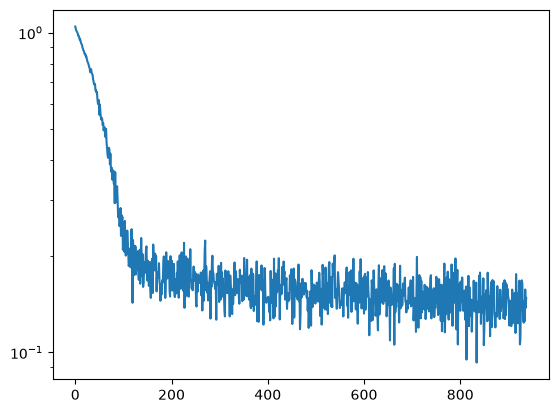

In [9]:
# Let's visually see how our losses look like for 2 epoch with only using our first approach.
plt.yscale("log")
plt.plot(stub_losses)

In [10]:
# Let's check and verify

t = torch.arange(1000, device=device)
# (1000, 64)
e = timestep_embedding(t, 64)
n = e / e.norm(dim=1, keepdim=True)

# Check the similarity here
sim = n @ n.T

# Check for some values comparing to 500 for similarities
for tv in [499, 500, 501, 510, 600, 900]:
    print(tv, sim[500, tv].item())


499 0.9661511182785034
500 1.000000238418579
501 0.9661509394645691
510 0.6578636169433594
600 0.5585835576057434
900 0.24231550097465515


In [11]:
# Let's test the ResBlock
b1 = ResBlock(32, 64, 128).to(device)
b2 = ResBlock(64, 64, 128).to(device)
x = torch.randn(4, 32, 32, 32, device=device)
temb = torch.randn(4, 128, device=device)

print(b1(x, temb).shape)
print(b2(b1(x, temb), temb).shape)

torch.Size([4, 64, 32, 32])
torch.Size([4, 64, 32, 32])


In [12]:
# Let's check for the first time for the model UNet
m = UNet()
print(m)
print(sum(p.numel() for p in m.parameters()))

UNet(
  (temb_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (stem): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (d1a): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Identity()
  )
  (d1b): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), s

Trained with uv run python train.py --epochs 40 --seed 0.

Loss went 1.04 → 0.0162 over 40 epochs (~3.5 h on an M1).

In [13]:
model = UNet().to(device)
print(model.load_state_dict(torch.load("ckpt_35.pt", map_location=device)))
model.eval()

<All keys matched successfully>


UNet(
  (temb_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (stem): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (d1a): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Identity()
  )
  (d1b): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=256, out_features=64, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), s

# Step 3 - Sampler

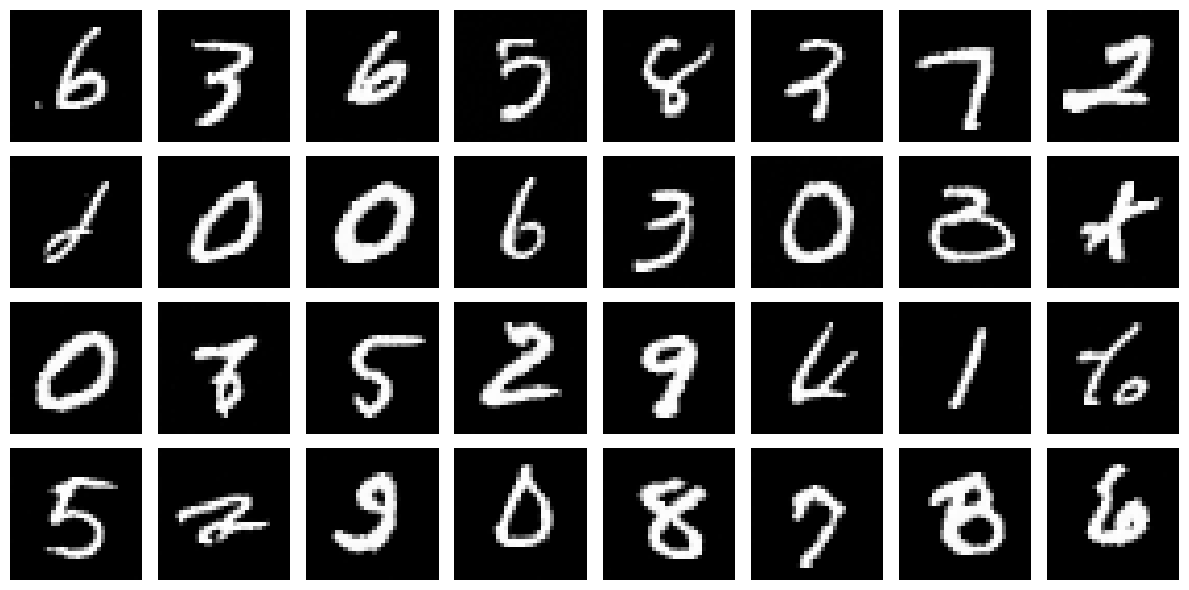

In [14]:
# Let's see what kind of samples we are able to get via our sampler function

out = sample(model, schedule, 32)
out = out.cpu()

fig, axes = plt.subplots(4, 8, figsize=[12,6])

for k in range(32):
    img = out[k].squeeze()
    img = (img + 1) / 2
    axes[k // 8, k % 8].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[k // 8, k % 8].axis("off")

fig.tight_layout()
plt.show()